In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Impostazioni grafiche generali
sns.set()
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# Opzioni di visualizzazione per i DataFrame
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [24]:
# URL del dataset OWID
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"

# Seleziono solo alcune colonne utili per l'analisi
cols = [
    "location", "continent", "date",
    "total_cases", "new_cases",
    "total_deaths", "new_deaths",
    "people_vaccinated", "people_fully_vaccinated",
    "population"
]

df = pd.read_csv(url, usecols=cols)

df.head()


,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,people_vaccinated,people_fully_vaccinated,population
0,Asia,Afghanistan,2020-01-05,0.00,0.00,0.00,0.00,NaN,NaN,41128772
1,Asia,Afghanistan,2020-01-06,0.00,0.00,0.00,0.00,NaN,NaN,41128772
2,Asia,Afghanistan,2020-01-07,0.00,0.00,0.00,0.00,NaN,NaN,41128772
3,Asia,Afghanistan,2020-01-08,0.00,0.00,0.00,0.00,NaN,NaN,41128772
4,Asia,Afghanistan,2020-01-09,0.00,0.00,0.00,0.00,NaN,NaN,41128772


In [25]:
# Dimensioni del dataset
print("Shape:", df.shape)

# Informazioni sulle colonne
df.info()
# Statistiche descrittive sulle colonne numeriche
df.describe()


Shape: (429435, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   continent                402910 non-null  object 
 1   location                 429435 non-null  object 
 2   date                     429435 non-null  object 
 3   total_cases              411804 non-null  float64
 4   new_cases                410159 non-null  float64
 5   total_deaths             411804 non-null  float64
 6   new_deaths               410608 non-null  float64
 7   people_vaccinated        81132 non-null   float64
 8   people_fully_vaccinated  78061 non-null   float64
 9   population               429435 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 32.8+ MB


,total_cases,new_cases,total_deaths,new_deaths,people_vaccinated,people_fully_vaccinated,population
count,"411,804.00","410,159.00","411,804.00","410,608.00","81,132.00","78,061.00","429,435.00"
mean,"7,365,292.35","8,017.36","81,259.57",71.85,"248,706,410.74","228,663,910.07","152,033,640.40"
std,"44,775,816.77","229,664.87","441,190.14","1,368.32","800,646,051.13","740,376,339.04","697,540,771.67"
min,0.00,0.00,0.00,0.00,0.00,1.00,47.00
25%,"6,280.75",0.00,43.00,0.00,"1,050,009.25","964,400.00","523,798.00"
50%,"63,653.00",0.00,799.00,0.00,"6,901,087.50","6,191,345.00","6,336,393.00"
75%,"758,272.00",0.00,"9,574.00",0.00,"50,932,952.00","47,731,850.00","32,969,520.00"
max,"775,866,783.00","44,236,227.00","7,057,132.00","103,719.00","5,631,263,739.00","5,177,942,957.00","7,975,105,024.00"


In [26]:
# Conversione della colonna 'date' in formato datetime
df["date"] = pd.to_datetime(df["date"])

# Rimuovo eventuali righe senza location
df = df[df["location"].notna()]

# Escludo gli aggregati (World, continents, ecc.), così lavoro solo sui singoli Paesi
aggregati = [
    "World", "European Union", "International",
    "Africa", "Asia", "Europe", "European Union",
    "North America", "South America", "Oceania"
]

df_countries = df[~df["location"].isin(aggregati)].copy()

print("Numero di Paesi:", df_countries["location"].nunique())
# Controllo la percentuale di valori nulli per ogni colonna
df_countries.isna().mean().sort_values(ascending=False)


Numero di Paesi: 248


people_fully_vaccinated   0.83
people_vaccinated         0.83
new_cases                 0.05
new_deaths                0.04
total_cases               0.04
total_deaths              0.04
continent                 0.04
location                  0.00
date                      0.00
population                0.00
dtype: float64

Intervallo temporale dei dati: 2020-01-01 → 2024-08-14


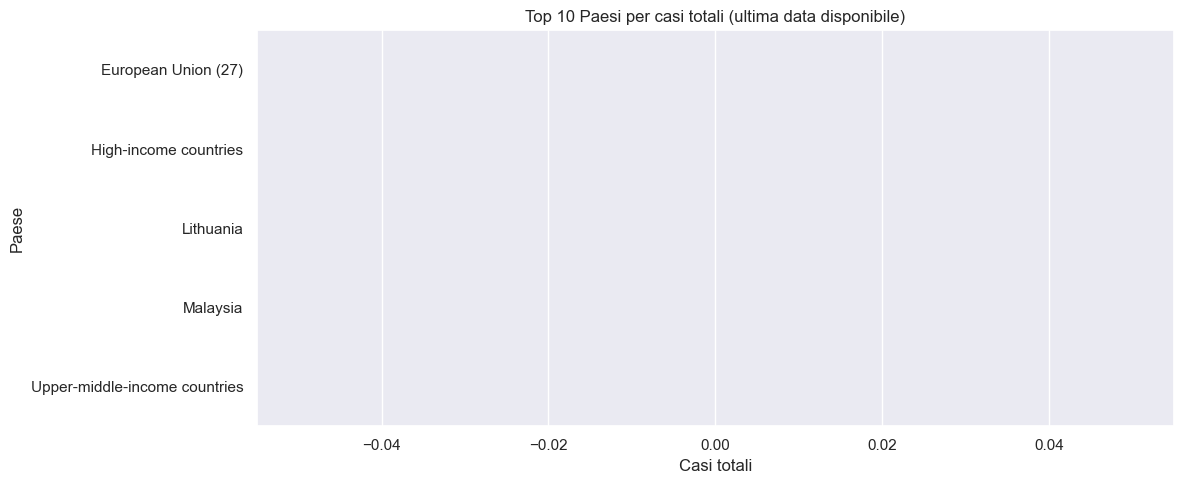

In [27]:
# Range temporale dei dati
start_date = df_countries["date"].min()
end_date = df_countries["date"].max()

print("Intervallo temporale dei dati:", start_date.date(), "→", end_date.date())
# Estraggo l'ultima data disponibile per ogni Paese
last_date = df_countries["date"].max()
last = df_countries[df_countries["date"] == last_date].copy()

# Ordino per casi totali
last_cases = last.sort_values("total_cases", ascending=False)

# Mostro i primi 10 Paesi per casi totali
last_cases[["location", "continent", "total_cases", "total_deaths"]].head(10)
# Grafico: Top 10 Paesi per casi totali
top10 = last_cases.head(10)

plt.figure()
sns.barplot(data=top10, x="total_cases", y="location")
plt.title("Top 10 Paesi per casi totali (ultima data disponibile)")
plt.xlabel("Casi totali")
plt.ylabel("Paese")
plt.tight_layout()
plt.show()


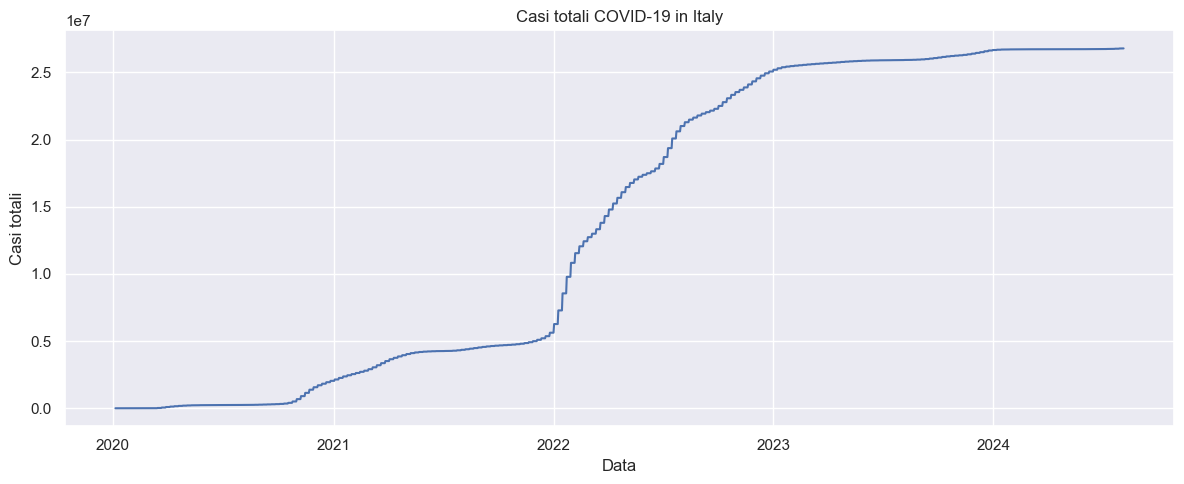

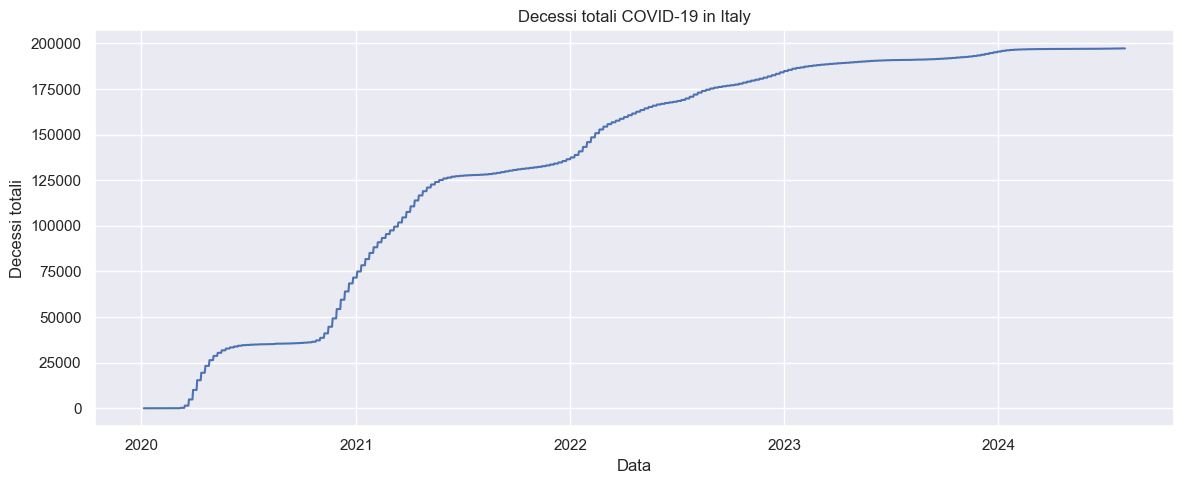

In [28]:
country_name = "Italy"

ita = df_countries[df_countries["location"] == country_name].copy()
ita.head()
# Andamento dei casi totali in Italia
plt.figure()
plt.plot(ita["date"], ita["total_cases"])
plt.title(f"Casi totali COVID-19 in {country_name}")
plt.xlabel("Data")
plt.ylabel("Casi totali")
plt.tight_layout()
plt.show()
# Andamento dei decessi totali in Italia
plt.figure()
plt.plot(ita["date"], ita["total_deaths"])
plt.title(f"Decessi totali COVID-19 in {country_name}")
plt.xlabel("Data")
plt.ylabel("Decessi totali")
plt.tight_layout()
plt.show()


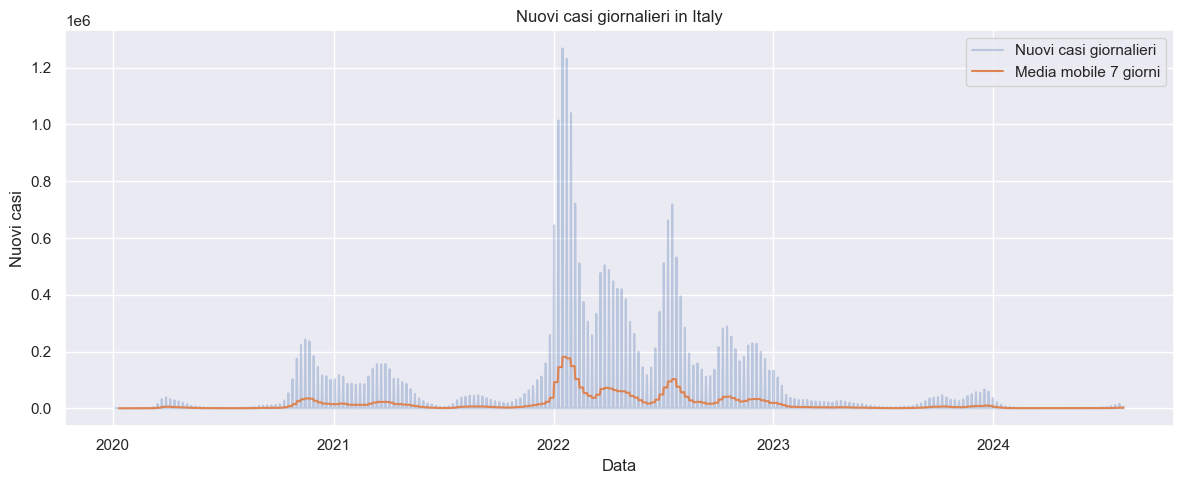

date         2022-01-16 00:00:00
new_cases           1,268,153.00
Name: 186017, dtype: object

In [29]:
# Calcolo della media mobile a 7 giorni sui nuovi casi
ita["new_cases_7d"] = ita["new_cases"].rolling(7).mean()

plt.figure()
plt.plot(ita["date"], ita["new_cases"], alpha=0.3, label="Nuovi casi giornalieri")
plt.plot(ita["date"], ita["new_cases_7d"], label="Media mobile 7 giorni")
plt.title(f"Nuovi casi giornalieri in {country_name}")
plt.xlabel("Data")
plt.ylabel("Nuovi casi")
plt.legend()
plt.tight_layout()
plt.show()
# Individuo il giorno con il picco di nuovi casi
peak_row = ita.loc[ita["new_cases"].idxmax(), ["date", "new_cases"]]
peak_row


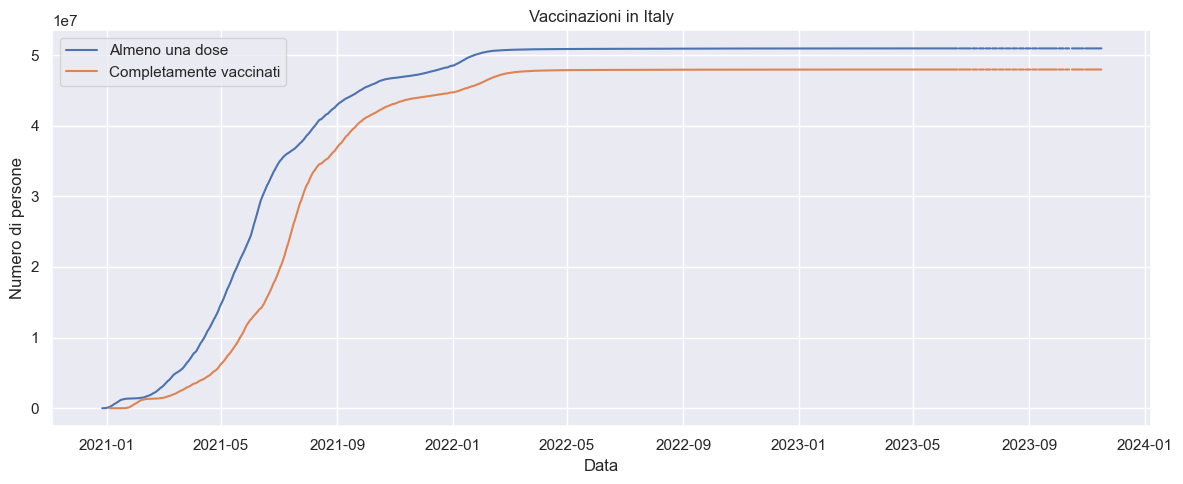

In [30]:
plt.figure()
plt.plot(ita["date"], ita["people_vaccinated"], label="Almeno una dose")
plt.plot(ita["date"], ita["people_fully_vaccinated"], label="Completamente vaccinati")
plt.title(f"Vaccinazioni in {country_name}")
plt.xlabel("Data")
plt.ylabel("Numero di persone")
plt.legend()
plt.tight_layout()
plt.show()


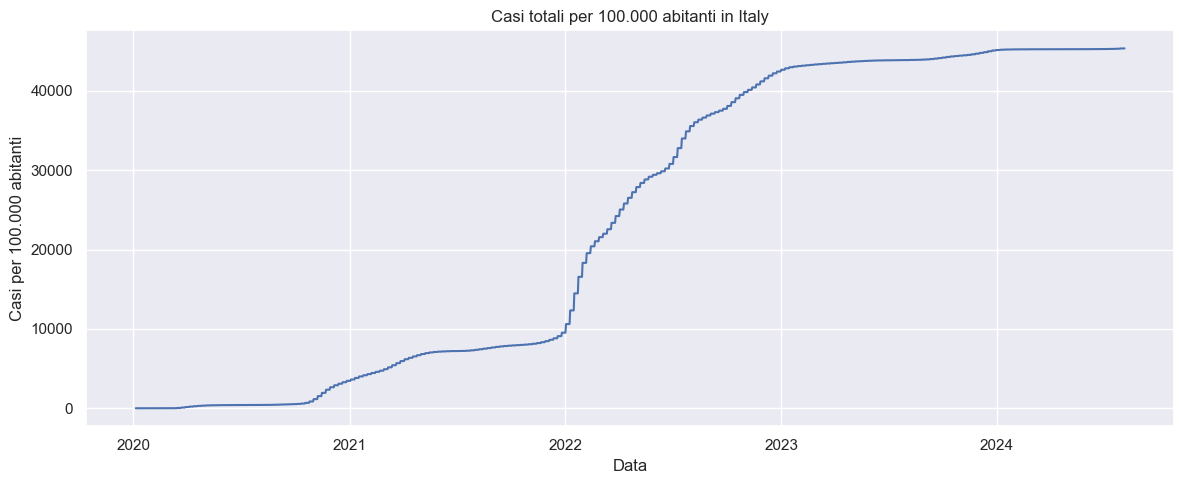

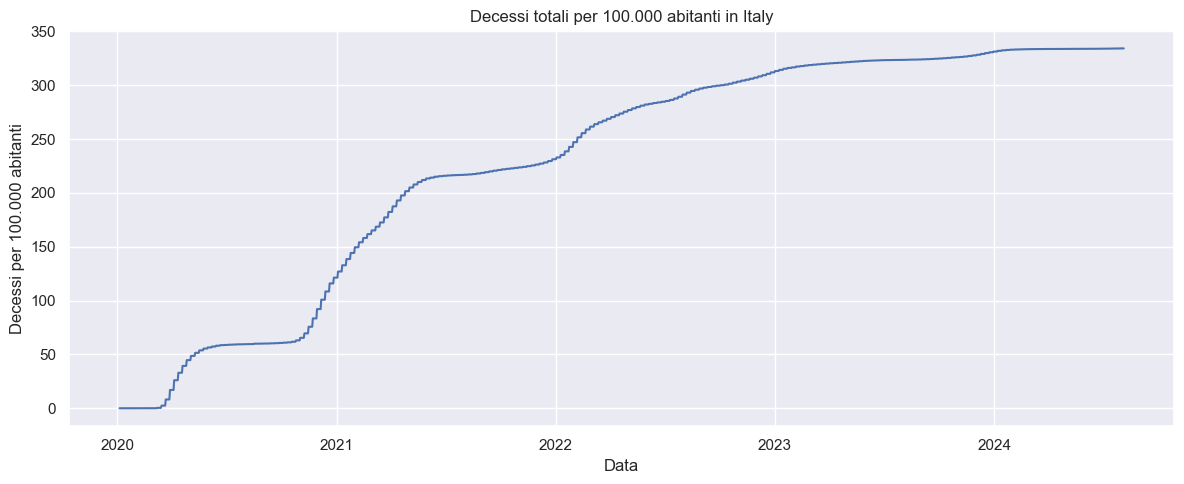

In [31]:
# Aggiungo casi e decessi per 100.000 abitanti
ita["cases_per_100k"] = ita["total_cases"] / ita["population"] * 100_000
ita["deaths_per_100k"] = ita["total_deaths"] / ita["population"] * 100_000

plt.figure()
plt.plot(ita["date"], ita["cases_per_100k"])
plt.title(f"Casi totali per 100.000 abitanti in {country_name}")
plt.xlabel("Data")
plt.ylabel("Casi per 100.000 abitanti")
plt.tight_layout()
plt.show()
plt.figure()
plt.plot(ita["date"], ita["deaths_per_100k"])
plt.title(f"Decessi totali per 100.000 abitanti in {country_name}")
plt.xlabel("Data")
plt.ylabel("Decessi per 100.000 abitanti")
plt.tight_layout()
plt.show()


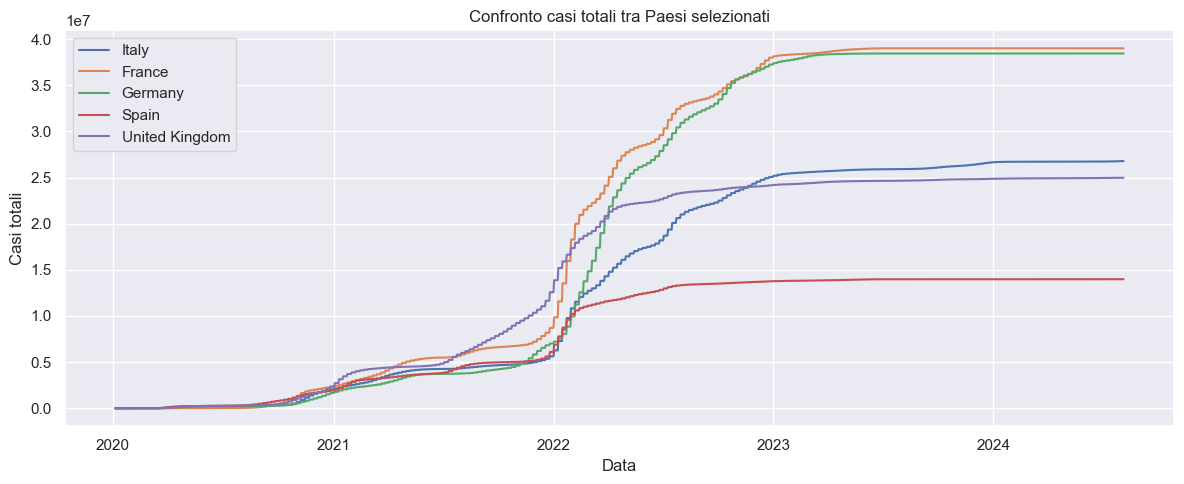

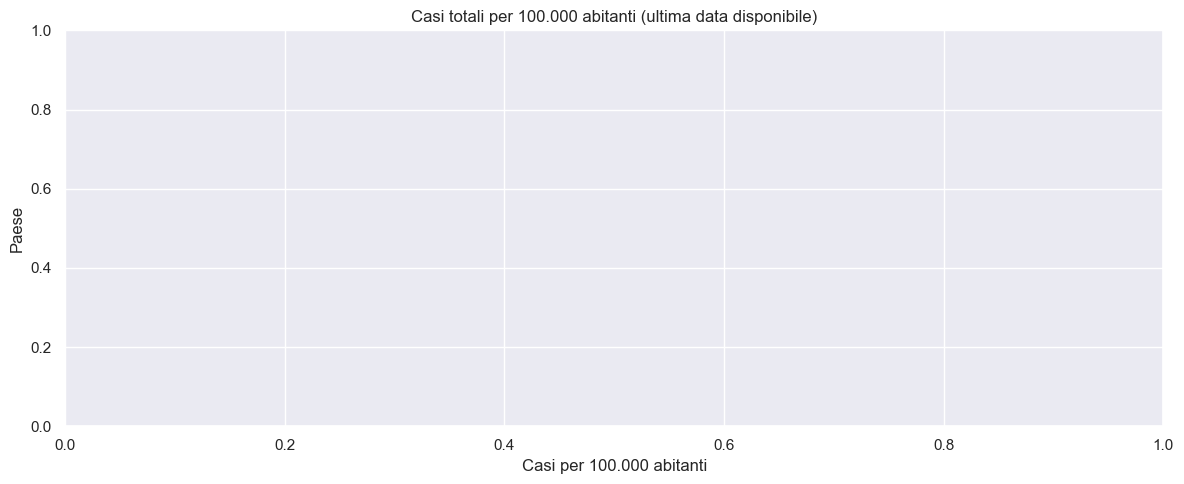

In [35]:
# Seleziono un gruppo di Paesi europei per il confronto
paesi = ["Italy", "France", "Germany", "Spain", "United Kingdom"]

df_sel = df_countries[df_countries["location"].isin(paesi)].copy()

plt.figure()
for p in paesi:
    tmp = df_sel[df_sel["location"] == p]
    plt.plot(tmp["date"], tmp["total_cases"], label=p)

plt.title("Confronto casi totali tra Paesi selezionati")
plt.xlabel("Data")
plt.ylabel("Casi totali")
plt.legend()
plt.tight_layout()
plt.show()
# Normalizzo i casi per 100.000 abitanti e confronto all'ultima data
df_sel["cases_per_100k"] = df_sel["total_cases"] / df_sel["population"] * 100_000

last_sel = df_sel[df_sel["date"] == last_date].copy()

plt.figure()
sns.barplot(
    data=last_sel.sort_values("cases_per_100k", ascending=False),
    x="cases_per_100k",
    y="location"
)
plt.title("Casi totali per 100.000 abitanti (ultima data disponibile)")
plt.xlabel("Casi per 100.000 abitanti")
plt.ylabel("Paese")
plt.tight_layout()
plt.show()


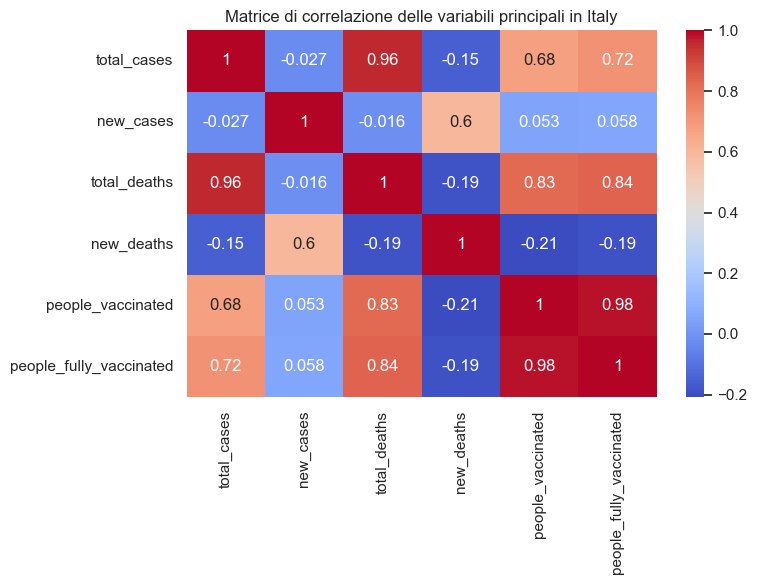

In [33]:
# Uso i dati dell'Italia per calcolare alcune correlazioni
corr_df = ita[[
    "total_cases", "new_cases",
    "total_deaths", "new_deaths",
    "people_vaccinated", "people_fully_vaccinated"
]].copy()

corr_df = corr_df.dropna()

corr = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title(f"Matrice di correlazione delle variabili principali in {country_name}")
plt.tight_layout()
plt.show()


In [ ]:
## Conclusioni

Dall’analisi svolta sui dati COVID-19 di Our World in Data emergono alcune considerazioni principali:

1. **Evoluzione temporale**
   - Il periodo coperto dal dataset va da 2020-01-01 a 2024-08-14.
   - In Italia l’andamento dei casi totali mostra una crescita inizialmente molto ripida, seguita da successive ondate con intensità diversa.

2. **Picchi di nuovi casi**
   - Il picco di **nuovi casi giornalieri** in Italia è stato registrato intorno a 2022-01-06 con circa 1,268,153.00 nuovi casi.
   - La media mobile a 7 giorni rende più leggibile l’andamento generale, attenuando la variabilità giornaliera.

3. **Mortalità e impatto sulla popolazione**
   - I decessi totali crescono in modo meno ripido rispetto ai casi, soprattutto nelle fasi successive, suggerendo un miglioramento delle cure e della gestione clinica.

4. **Vaccinazioni**
   - Le curve di **persone vaccinate** e **completamente vaccinate** mostrano una forte crescita a partire dall’inizio delle campagne vaccinali.
   - L’aumento della copertura vaccinale coincide, nelle fasi successive, con una riduzione della gravità delle ondate (meno decessi rispetto ai casi).

5. **Confronto tra Paesi**
   - Nel confronto tra Italia, Francia, Germania, Spagna e Regno Unito, emergono differenze sia nei livelli assoluti di casi, sia nei casi **normalizzati per 100.000 abitanti**.
   - Alcuni Paesi hanno avuto un numero di casi totali più elevato, ma l’impatto relativo sulla popolazione può risultare diverso osservando le metriche normalizzate.

6. **Correlazioni**
   - La matrice di correlazione mostra una forte relazione tra **casi totali** e **decessi totali**, come previsto.
   - Le variabili legate alle **vaccinazioni** risultano collegate all’andamento temporale della pandemia.

